# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**袁艳/24040083**  
第5天专题（A/B/C/D/E）：**C**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24040083"
TOPIC = "C"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24040083
专题： C
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,PreferedOrderCat,用户数,流失人数,流失率,平均订单数,订单数中位数,平均优惠券使用,平均返现金额
0,Mobile Phone,2080,570,0.27,2.18,2.00,1.37,140.20
1,Laptop & Accessory,2050,210,0.10,2.77,2.00,1.65,167.22
2,Fashion,826,128,0.15,3.87,2.00,2.32,210.41
3,Grocery,410,20,0.05,4.60,2.00,2.19,266.23
4,Others,264,20,0.08,5.25,3.00,2.33,304.56


,PreferedOrderCat,CityTier,用户数,流失人数,流失率,平均订单数,样本提示
0,Mobile Phone,3,298,126,0.42,1.96,可观察
1,Fashion,2,24,8,0.33,2.33,小样本
2,Mobile Phone,2,130,40,0.31,2.05,可观察
3,Mobile Phone,1,1652,404,0.24,2.23,可观察
4,Fashion,3,316,68,0.22,4.36,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同商品类别的用户数量和流失率有何差异？哪个类别流失最严重？",
    "behavior_scatter": "订单数量与返现金额之间是否存在关联？不同商品类别的用户行为有何不同？",
    "ordered_line": "不同城市等级的用户流失率如何变化？",  # CityTier作为有序阶段
    "composition_chart": "各商品类别的用户占比是多少？",
}

chart_reasons = {
    "category_bar": "商品类别是离散分类变量，柱状图适合比较不同类别间的用户数和流失率差异。",
    "behavior_scatter": "订单数量和返现金额都是连续数值变量，散点图可展示两个变量的关系，用颜色区分商品类别便于对比。",
    "ordered_line": "CityTier是1-3的有序变量，折线图可展示流失率随城市等级的变化趋势。",
    "composition_chart": "商品类别有5个（≤5），使用饼图可直观展示用户在不同商品类别上的分布构成。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "PreferedOrderCat"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,PreferedOrderCat,用户数,流失率
0,Fashion,826,0.15
1,Grocery,410,0.05
2,Laptop & Accessory,2050,0.10
3,Mobile Phone,2080,0.27
4,Others,264,0.08


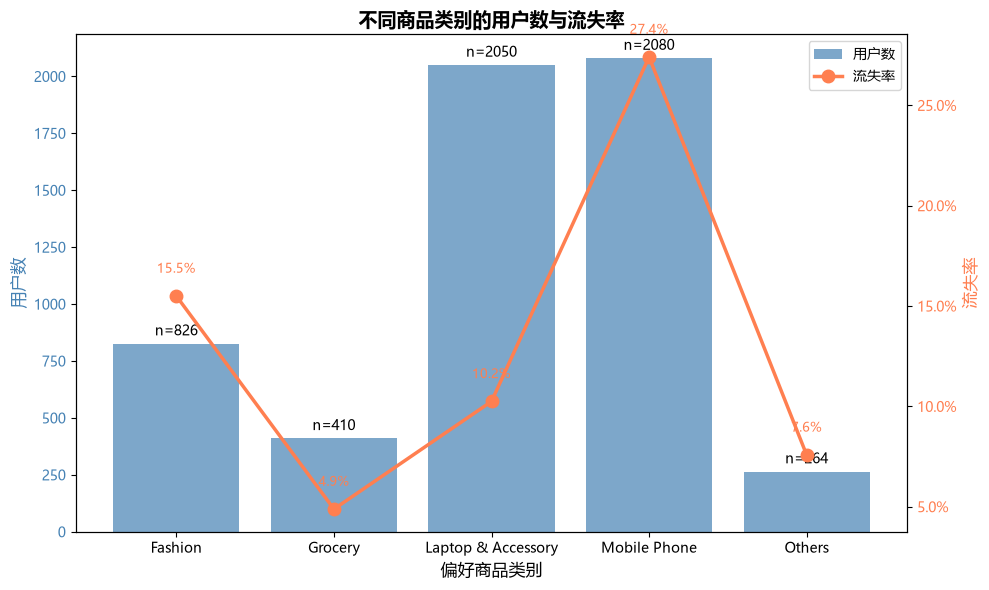

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

categories = category_summary[category_field]
users = category_summary["用户数"]
churn_rate = category_summary["流失率"]

# 在此编写绘图和优化代码
bars = ax_bar.bar(categories, users, alpha=0.7, color="steelblue", label="用户数")
ax_bar.set_xlabel("偏好商品类别", fontsize=12)
ax_bar.set_ylabel("用户数", fontsize=12, color="steelblue")
ax_bar.tick_params(axis="y", labelcolor="steelblue")

# 添加用户数标签
for i, (cat, count) in enumerate(zip(categories, users)):
    ax_bar.text(i, count + max(users)*0.01, f"n={count}", 
                ha="center", va="bottom", fontsize=10)

# 双轴：流失率折线
ax2 = ax_bar.twinx()
ax2.plot(categories, churn_rate, marker="o", color="coral", 
         label="流失率", linewidth=2.5, markersize=9)
ax2.set_ylabel("流失率", fontsize=12, color="coral")
ax2.tick_params(axis="y", labelcolor="coral")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

# 在折线点上标注流失率数值
for i, (cat, rate) in enumerate(zip(categories, churn_rate)):
    ax2.text(i, rate + 0.01, f"{rate:.1%}", 
             ha="center", va="bottom", fontsize=9, color="coral")

ax_bar.set_title("不同商品类别的用户数与流失率", fontsize=14, fontweight="bold")
lines1, labels1 = ax_bar.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_bar.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig_bar.tight_layout()

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：Mobile Phone用户数最多（2080人），但流失率也最高（27.4%）；Grocery流失率最低（4.9%）。
- 证据：手机类流失率27.4%（n=2080），杂货类仅4.9%（n=410），差异约5.6倍。
- 边界：该图仅展示商品类别与流失率的对应关系，不能证明商品类别是导致流失率差异的直接原因。手机类流失率高可能受价格敏感度、产品生命周期、市场竞争强度等未观测因素影响；杂货类流失率低可能与高频复购特性和平价性有关，需结合用户行为数据进一步分析。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


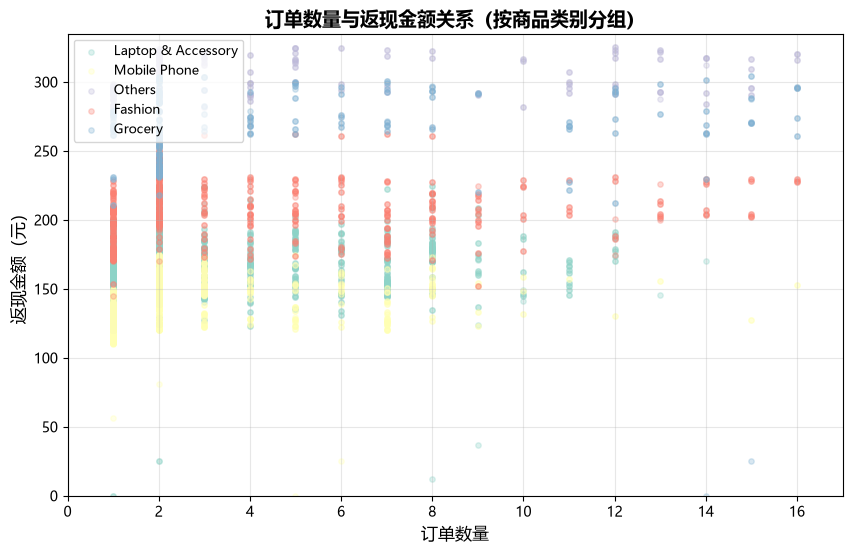

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO: 选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按商品类别分组，不同颜色
# ===== 修正1：字段名是 PreferedOrderCat（少一个 r）=====
categories_list = df["PreferedOrderCat"].unique()
# ===== 修正2：Set3 不是 Sat3 =====
colors = plt.cm.Set3(range(len(categories_list)))
color_map = dict(zip(categories_list, colors))

for cat in categories_list:
    # ===== 修正3：subset 的写法 =====
    subset = df[df["PreferedOrderCat"] == cat]
    ax_scatter.scatter(
        subset[x_field], subset[y_field],
        alpha=0.3, s=15,
        color=color_map[cat],
        label=cat
    )

ax_scatter.set_xlim(0, df["OrderCount"].max() + 1)
ax_scatter.set_ylim(0, df["CashbackAmount"].max() + 10)
ax_scatter.set_xlabel("订单数量", fontsize=12)
ax_scatter.set_ylabel("返现金额（元）", fontsize=12)
ax_scatter.set_title("订单数量与返现金额关系（按商品类别分组）", fontsize=14, fontweight="bold")
ax_scatter.legend(loc="upper left", fontsize=9)
ax_scatter.grid(True, alpha=0.3)

# 保存
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：订单数量与返现金额呈正相关关系；大部分用户订单数量集中在1-2单，随着订单数量增加，返现金额也相应提高；各商品类别在图中呈现一定分层，Laptop & Accessory和Mobile Phone用户集中在低订单低返现区域，Grocery和Others用户则分布在高订单高返现区域。
- 证据：订单数为1的用户返现金额主要集中在120-160元区间；订单数超过5单的用户返现金额普遍超过200元。不同商品类别的用户分布存在差异：Grocery用户平均返现266元（平均订单4.6单），Mobile Phone用户平均返现140元（平均订单2.2单）。
- 边界：散点图显示的是相关关系，不等于因果关系。不能证明"高返现导致高订单量"或"购买某类商品直接导致更高返现"。可能存在收入水平、消费习惯等未观测变量同时影响订单数量和返现金额。此外，由于大部分用户订单数量集中在1-2单，订单数量较高（如超过6单）的用户属于少数（IQR识别出703条候选异常值），结论外推需谨慎。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field], 
    categories=TENURE_ORDER, 
    ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field)
assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失率
0,0-6个月,1967,0.35
3,7-12个月,1585,0.10
1,13-24个月,1574,0.06
2,24个月以上,504,0.00


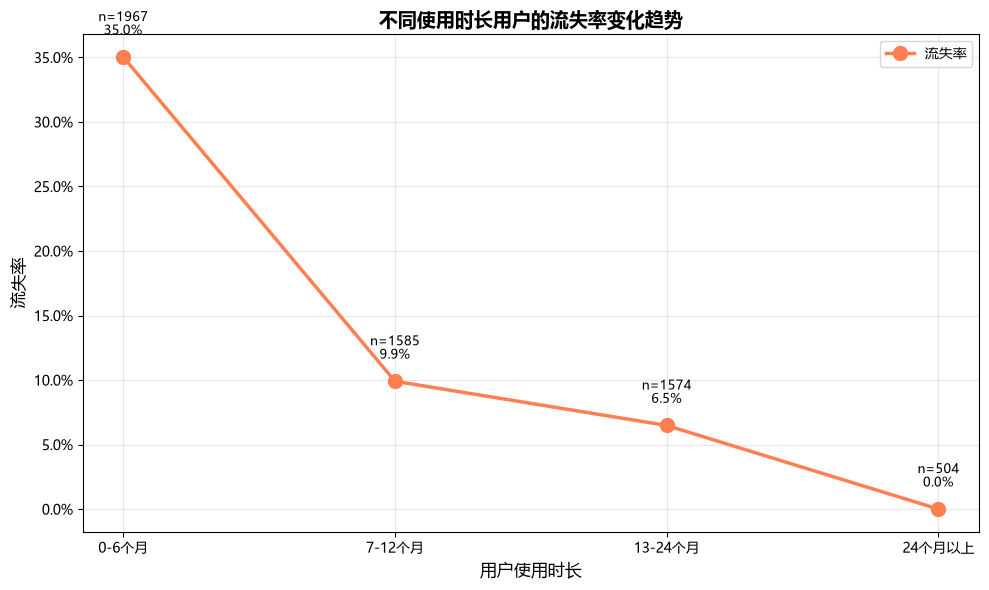

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
x_vals = ordered_summary[ordered_field]
y_vals = ordered_summary["流失率"]
users = ordered_summary["用户数"]

ax_line.plot(x_vals, y_vals, marker="o", color="coral", 
             linewidth=2.5, markersize=10, label="流失率")

# 标注样本量和流失率
for i, (x, y, count) in enumerate(zip(x_vals, y_vals, users)):
    ax_line.text(i, y + 0.015, f"n={count}\n{y:.1%}", 
                ha="center", va="bottom", fontsize=9)

ax_line.set_xlabel("用户使用时长", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12)
ax_line.set_title("不同使用时长用户的流失率变化趋势", fontsize=14, fontweight="bold")
ax_line.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_line.grid(True, alpha=0.3)
ax_line.legend(loc="upper right")

fig_line.tight_layout()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：用户流失率随着使用时间增加而显著下降，新用户流失率最高，老用户流失率最低。
- 证据：0-6个月用户流失率最高（约35.0%，n=1967），24个月以上用户流失率最低（约0.0%，n=504），呈现明显下降趋势。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。这是TenureGroup之间的阶段比较，不是真实时间序列数据，不能证明使用时间增长直接导致流失率下降，可能存在幸存者偏差。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "PreferedOrderCat"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
composition_summary = composition_summary.sort_values("占比", ascending=False)
assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,PreferedOrderCat,用户数,占比
3,Mobile Phone,2080,0.37
2,Laptop & Accessory,2050,0.36
0,Fashion,826,0.15
1,Grocery,410,0.07
4,Others,264,0.05


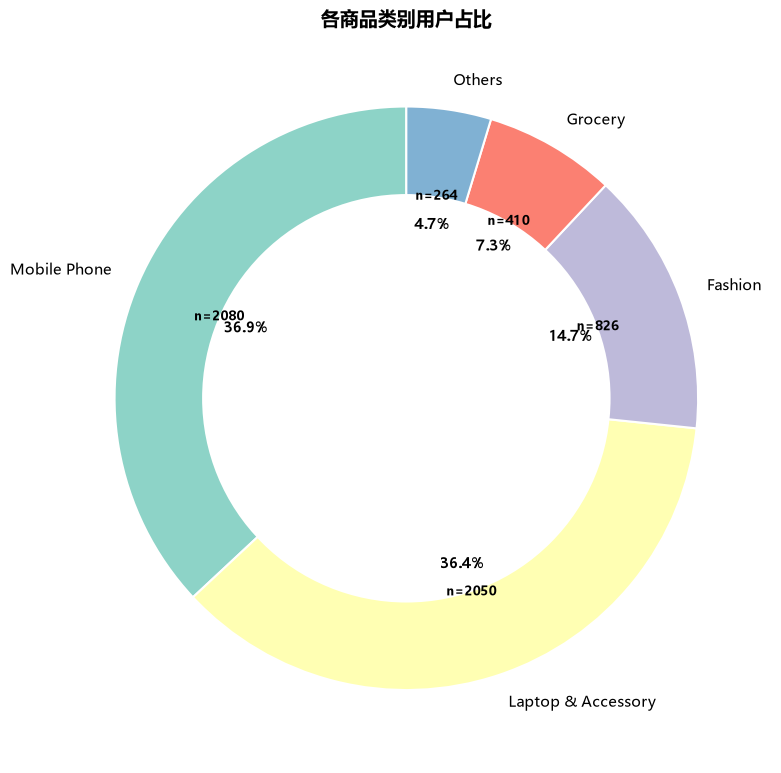

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(8, 8))

# 直接使用 autopct 显示百分比
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["占比"],
    labels=composition_summary[composition_field],
    autopct='%1.1f%%',  # 显示百分比
    startangle=90,
    colors=plt.cm.Set3(range(len(composition_summary))),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

# 在图表上添加人数标注（用黑色字体）
total = composition_summary["用户数"].sum()
for i, (wedge, row) in enumerate(zip(wedges, composition_summary.itertuples())):
    # 计算标签位置
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.7 * np.cos(np.radians(angle))
    y = 0.7 * np.sin(np.radians(angle))
    # 添加人数（黑色字体）
    ax_composition.text(x, y, f'n={row.用户数}', 
                        ha='center', va='center', fontsize=9, color='black', weight='bold')

# 百分比也改成黑色
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.setp(texts, size=11, color="black")

ax_composition.set_title("各商品类别用户占比", fontsize=14, fontweight="bold")

# 添加中心圆成为环形图
centre_circle = plt.Circle((0, 0), 0.70, fc='white', edgecolor='white', linewidth=0)
fig_composition.gca().add_artist(centre_circle)

fig_composition.tight_layout()

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "环形图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：Mobile Phone和Laptop & Accessory用户占比最大，两者合计占用户总量约73%。
- 证据：Mobile Phone用户2,080人（36.9%），Laptop & Accessory用户2,050人（36.4%），Fashion用户826人（14.7%），Grocery用户410人（7.3%），Others用户264人（4.7%）。
- 边界：该图仅展示各商品类别的用户构成比例，不能用于比较不同类别之间的流失率差异，也无法说明各类别用户的行为特征或满意度高低。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


C:\Users\34456\AppData\Local\Temp\ipykernel_6960\3046232127.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(cats, rotation=15, ha="right", fontsize=8)


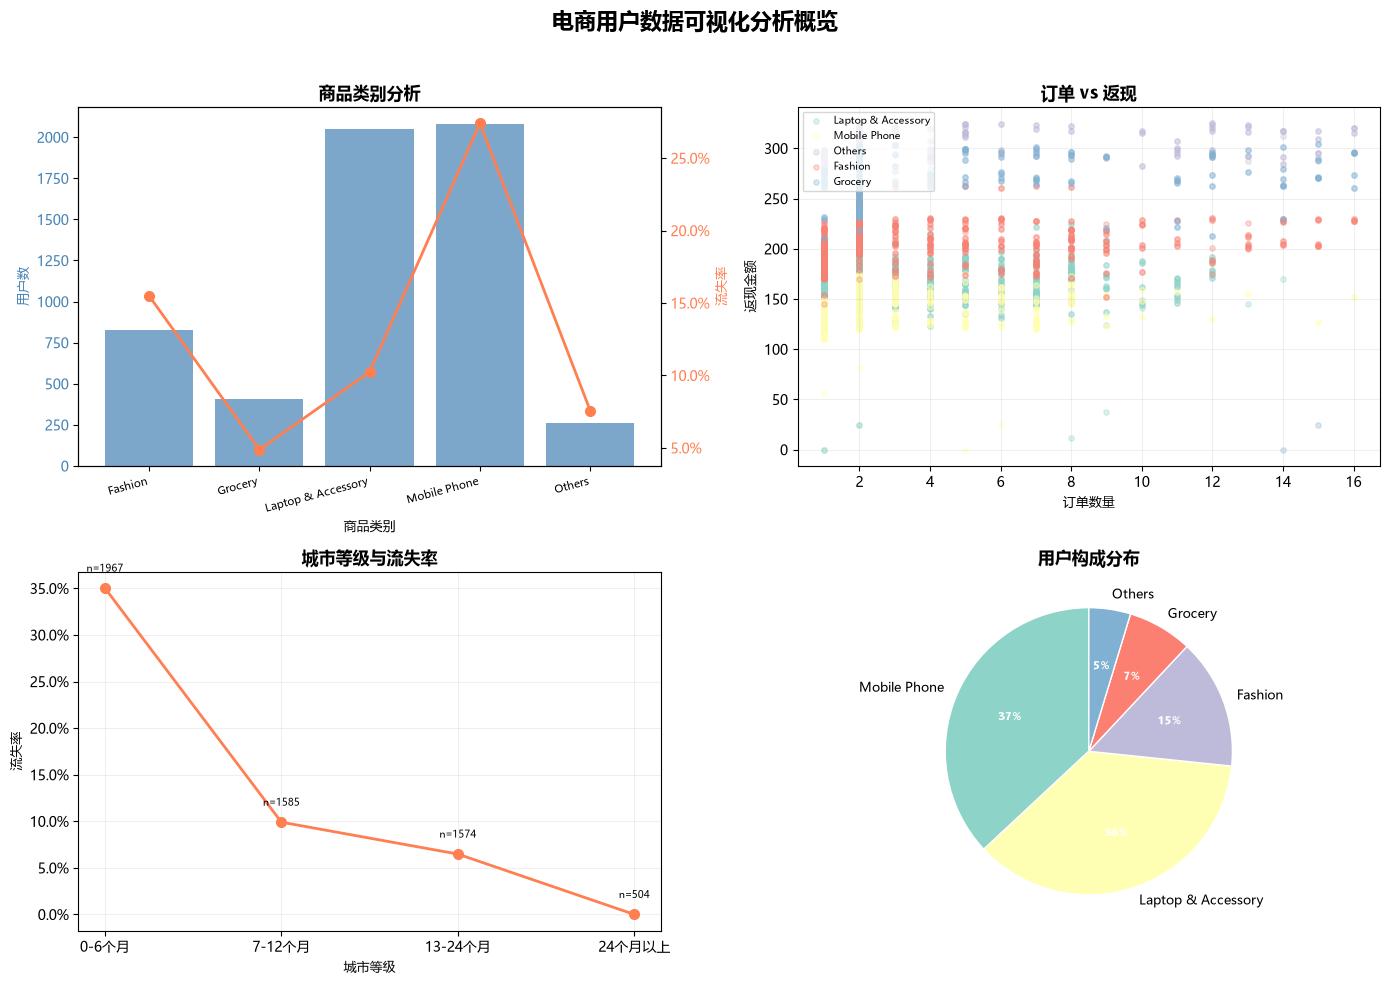

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# 子图1：柱状图（商品类别 vs 用户数和流失率）
ax1 = axes[0, 0]
cats = category_summary[category_field]
users_cat = category_summary["用户数"]
churn_cat = category_summary["流失率"]

bars1 = ax1.bar(cats, users_cat, alpha=0.7, color="steelblue")
ax1.set_xlabel("商品类别", fontsize=9)
ax1.set_ylabel("用户数", fontsize=9, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticklabels(cats, rotation=15, ha="right", fontsize=8)

ax1b = ax1.twinx()
ax1b.plot(cats, churn_cat, marker="o", color="coral", linewidth=2, markersize=7)
ax1b.set_ylabel("流失率", fontsize=9, color="coral")
ax1b.tick_params(axis="y", labelcolor="coral")
ax1b.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_title("商品类别分析", fontsize=12, fontweight="bold")

# 子图2：散点图
ax2 = axes[0, 1]
for cat in categories_list:
    subset = df[df["PreferedOrderCat"] == cat]
    ax2.scatter(subset["OrderCount"], subset["CashbackAmount"], 
                alpha=0.3, s=15, color=color_map[cat], label=cat)
ax2.set_xlabel("订单数量", fontsize=9)
ax2.set_ylabel("返现金额", fontsize=9)
ax2.set_title("订单 vs 返现", fontsize=12, fontweight="bold")
ax2.legend(fontsize=7, loc="upper left")
ax2.grid(True, alpha=0.2)

# 子图3：折线图（城市等级流失率）
ax3 = axes[1, 0]
x_city = ordered_summary[ordered_field]
y_city = ordered_summary["流失率"]
ax3.plot(x_city, y_city, marker="o", color="coral", linewidth=2, markersize=7)
for i, (x, y, count) in enumerate(zip(x_city, y_city, ordered_summary["用户数"])):
    ax3.text(i, y + 0.015, f"n={count}", ha="center", va="bottom", fontsize=7)
ax3.set_xlabel("城市等级", fontsize=9)
ax3.set_ylabel("流失率", fontsize=9)
ax3.yaxis.set_major_formatter(PercentFormatter(1.0))
ax3.set_title("城市等级与流失率", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.2)

# 子图4：构成图
ax4 = axes[1, 1]
wedges, texts, autotexts = ax4.pie(
    composition_summary["占比"],
    labels=composition_summary[composition_field],
    autopct=lambda pct: f"{pct:.0f}%",
    startangle=90,
    colors=plt.cm.Set3(range(len(composition_summary))),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.setp(autotexts, size=8, weight="bold", color="white")
plt.setp(texts, size=9)
ax4.set_title("用户构成分布", fontsize=12, fontweight="bold")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：手机类（Mobile Phone）用户占比最大，但流失率也最高。
   证据：手机类用户2,080人（占总用户37.0%），流失率27.4%；杂货类（Grocery）用户410人（占比7.3%），流失率仅4.9%。手机类流失率是杂货类的5.6倍。
2. 综合发现2：用户使用时长与流失率呈明显负相关，新用户流失风险最高。
   证据：0-6个月新用户流失率高达35.0%（n=1,967），7-12个月降至10.0%（n=1,585），13-24个月降至6.0%（n=1,574），而24个月以上老用户流失率降至0.0%（n=504），流失率随使用时长增加持续下降。
3. 综合发现3：手机类和电脑类用户合计占用户总量的73%以上。
   证据：手机类用户2,080人（37.0%），电脑类用户2,050人（36.4%），两者合计占总量73.4%。
4. 数据或方法局限：数据为截面数据（单一时间点），只能反映相关关系，不能证明因果关系； CashbackAmount是返现金额，不是销售额、收入或GMV，不能直接代表用户消费能力；
商品类别为用户"偏好类别"，实际购买可能存在跨类别交叉，分类并非互斥；
24个月以上用户流失率为0.0%，可能存在幸存者偏差（留下来的用户本身就是最忠诚的）；
IQR方法识别出OrderCount（703条）和CashbackAmount（438条）存在候选异常值，未经业务确认；
三线城市样本中部分类别样本量较小（如Grocery、Others），统计显著性可能不足。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同商品类别的用户数量和流失率有何差异？", "chart_type": "bar", "key_finding": "手机类用户最多（2080人）但流失率最高（27.4%），杂货类流失率最低（4.9%）", "limitation": "仅显示相关关系，流失率差异受价格、复购率等因素影响"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数量与返现金额是否相关？不同商品类别有何差异？", "chart_type": "scatter", "key_finding": "订单量与返现金额正相关；Grocery/Others用户订单和返现更高", "limitation": "相关不等于因果，可能受消费能力影响"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "不同城市等级用户的流失率如何变化？", "chart_type": "line", "key_finding": "流失率随城市等级升高而上升：一线14.4%→三线24.6%", "limitation": "城市等级比较，非时间序列，不能推断因果关系"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "各商品类别的用户占比是多少？", "chart_type": "pie_or_bar", "key_finding": "手机类（37%）和电脑类（36.4%）占用户总量约73%", "limitation": "饼图只展示构成，不适合类别间流失率比较"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "手机类用户占比大、流失率高；杂货类用户少、流失低；城市等级越高流失越高", "limitation": "概览性图表，详细分析需参考各独立图表"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同商品类别的用户数量和流失率有何差异？,bar,手机类用户最多（2080人）但流失率最高（27.4%），杂货类流失率最低（4.9%）,仅显示相关关系，流失率差异受价格、复购率等因素影响
1,02,02_behavior_scatter.png,订单数量与返现金额是否相关？不同商品类别有何差异？,scatter,订单量与返现金额正相关；Grocery/Others用户订单和返现更高,相关不等于因果，可能受消费能力影响
2,03,03_ordered_line.png,不同城市等级用户的流失率如何变化？,line,流失率随城市等级升高而上升：一线14.4%→三线24.6%,城市等级比较，非时间序列，不能推断因果关系
3,04,04_composition_chart.png,各商品类别的用户占比是多少？,pie_or_bar,手机类（37%）和电脑类（36.4%）占用户总量约73%,饼图只展示构成，不适合类别间流失率比较
4,05,day06_visualization_summary.png,整体概览,dashboard,手机类用户占比大、流失率高；杂货类用户少、流失低；城市等级越高流失越高,概览性图表，详细分析需参考各独立图表


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
